# Projet: Etude Customers Products Sales Suppliers

# 1 - Question générales sur les données

## Import et création de la DataFrame

In [4]:
# import des packages
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

In [5]:
# Chemin vers le dossier contenant les fichiers CSV
path = r'C:\Users\diakh\Bureau\DA_course\CasPratique_Analyse_Ventes\sales_customers_products'

In [6]:
# Charger le fichier Excel
fichier_xls = pd.ExcelFile(path + '/Calculated Field Examples.xlsx')

In [7]:
# Afficher les noms des onglets disponibles
print(fichier_xls.sheet_names)

['Sales', 'Customers', 'Product', 'supplier']


In [8]:
# Lire les onglets 
df_sales = fichier_xls.parse('Sales')
df_customers = fichier_xls.parse('Customers')
df_products = fichier_xls.parse('Product')
df_suppliers = fichier_xls.parse('supplier')

In [9]:
df_sales.head(1)

,Sale_ID,Customer_ID,Product_ID,Date,Quantity,Price,Discount
0,1001,C001,P001,2024-01-01,2,20.0,0.05


In [10]:
df_customers.head(1)

,Customer_ID,Name,Age,Gender,Region
0,C001,Jack Allen,28,F,West Coast


In [11]:
df_products.head(1)

,Product_ID,Product_Name,Category,Supplier_ID,Cost_Price
0,P001,Widget A,Electronics,S001,15.0


In [12]:
df_suppliers.head(1)

,Supplier_ID,Supplier_Name,Contact_Person,Contact_Email,City,State
0,S001,Gadget World,Emily Rose,emily@gadgetworld.com,New York,NY


In [13]:
# Sauvegarder chaque DataFrame en tant que fichier CSV
df_sales.to_csv(path + '/df_sales.csv', index=False)
df_customers.to_csv(path + '/df_customers.csv', index=False)
df_products.to_csv(path + '/df_products.csv', index=False)
df_suppliers.to_csv(path + '/df_suppliers.csv', index=False)

In [14]:
# Fusion de df_sales et df_customers dans une df1
df1 = df_sales.merge(right = df_customers, on = 'Customer_ID', how = 'left')
df1.head(1)

,Sale_ID,Customer_ID,Product_ID,Date,Quantity,Price,Discount,Name,Age,Gender,Region
0,1001,C001,P001,2024-01-01,2,20.0,0.05,Jack Allen,28,F,West Coast


In [15]:
# Fusion de df1 et df_products dans une df2
df2 = df1.merge(right = df_products, on = 'Product_ID', how = 'left')
df2.head(1)

,Sale_ID,Customer_ID,Product_ID,Date,Quantity,Price,Discount,Name,Age,Gender,Region,Product_Name,Category,Supplier_ID,Cost_Price
0,1001,C001,P001,2024-01-01,2,20.0,0.05,Jack Allen,28,F,West Coast,Widget A,Electronics,S001,15.0


In [16]:
# Fusion de df2 et df_suppliers dans une all_data
all_data = df2.merge(right = df_suppliers, on = 'Supplier_ID', how = 'left')

In [17]:
display(all_data)

,Sale_ID,Customer_ID,Product_ID,Date,Quantity,Price,Discount,Name,Age,Gender,Region,Product_Name,Category,Supplier_ID,Cost_Price,Supplier_Name,Contact_Person,Contact_Email,City,State
0,1001,C001,P001,2024-01-01,2,20.0,0.050000,Jack Allen,28,F,West Coast,Widget A,Electronics,S001,15.00,Gadget World,Emily Rose,emily@gadgetworld.com,New York,NY
1,1002,C002,P002,2024-01-01,1,35.0,0.100000,Xander Jones,66,F,Midwest,Gadget B,Home Appliances,S002,25.00,Tech Gear Co.,John Taylor,john@techgear.com,Los Angeles,CA
2,1003,C001,P003,2024-01-01,3,15.0,0.000000,Jack Allen,28,F,West Coast,Tool C,Hardware,S003,10.00,Circuit Solutions,Mark Johnson,mark@circuitsolutions.com,San Francisco,CA
3,1004,C056,P005,2024-01-01,4,35.0,0.050000,Carol Lee,20,F,Midwest,Device E,Electronics,S005,30.00,Office Tech Depot,Kevin Lee,kevin@officetechdepot.com,Chicago,IL
4,1005,C035,P050,2024-01-01,1,20.0,0.059285,Jack Hill,41,M,East Coast,Accessory AX,Accessories,S010,8.75,Sports Tech Gear,Michael Harris,michael@sportstechgear.com,Denver,CO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6130,7131,C130,P009,2024-12-31,1,36.0,0.015837,Alice King,60,M,Midwest,Tool I,Hardware,S009,18.00,Gourmet Gadgets,Alice Brown,alice@gourmetgadgets.com,Seattle,WA
6131,7132,C035,P017,2024-12-31,7,80.0,0.095424,Jack Hill,41,M,East Coast,Appliance Q,Home Appliances,S007,40.00,HealthTech Supplies,Peter Clark,peter@healthtech.com,Miami,FL
6132,7133,C036,P017,2024-12-31,3,80.0,0.044273,Uma Brown,39,M,North,Appliance Q,Home Appliances,S007,40.00,HealthTech Supplies,Peter Clark,peter@healthtech.com,Miami,FL
6133,7134,C046,P026,2024-12-31,1,22.0,0.048924,Mia Jones,56,M,East Coast,Item Z,Office Supplies,S006,11.00,Eco Electronics,Linda Parker,linda@ecoelectronics.com,Portland,OR


In [18]:
# Sauvegarde de la DataFrame
#all_data.to_csv(path + '/all_data.csv', index=False)

In [19]:
# info
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6135 entries, 0 to 6134
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Sale_ID         6135 non-null   int64         
 1   Customer_ID     6135 non-null   object        
 2   Product_ID      6135 non-null   object        
 3   Date            6135 non-null   datetime64[ns]
 4   Quantity        6135 non-null   int64         
 5   Price           6135 non-null   float64       
 6   Discount        6135 non-null   float64       
 7   Name            6135 non-null   object        
 8   Age             6135 non-null   int64         
 9   Gender          6135 non-null   object        
 10  Region          6135 non-null   object        
 11  Product_Name    6135 non-null   object        
 12  Category        6135 non-null   object        
 13  Supplier_ID     6135 non-null   object        
 14  Cost_Price      6135 non-null   float64       
 15  Supp

## Qualité des données

In [21]:
# Valeurs Manquantes?
nan_all_data = all_data.isna().sum()
nan_all_data

Sale_ID           0
Customer_ID       0
Product_ID        0
Date              0
Quantity          0
Price             0
Discount          0
Name              0
Age               0
Gender            0
Region            0
Product_Name      0
Category          0
Supplier_ID       0
Cost_Price        0
Supplier_Name     0
Contact_Person    0
Contact_Email     0
City              0
State             0
dtype: int64

In [22]:
# Pas de valeurs manquantes

In [23]:
# Types de données?
all_data.dtypes

Sale_ID                    int64
Customer_ID               object
Product_ID                object
Date              datetime64[ns]
Quantity                   int64
Price                    float64
Discount                 float64
Name                      object
Age                        int64
Gender                    object
Region                    object
Product_Name              object
Category                  object
Supplier_ID               object
Cost_Price               float64
Supplier_Name             object
Contact_Person            object
Contact_Email             object
City                      object
State                     object
dtype: object

## Propriétés des variables

In [25]:
# Afficher les noms des colonnes
column_names = all_data.columns
print(column_names)

Index(['Sale_ID', 'Customer_ID', 'Product_ID', 'Date', 'Quantity', 'Price',
       'Discount', 'Name', 'Age', 'Gender', 'Region', 'Product_Name',
       'Category', 'Supplier_ID', 'Cost_Price', 'Supplier_Name',
       'Contact_Person', 'Contact_Email', 'City', 'State'],
      dtype='object')


In [26]:
# Affichage du nombre de colonnes de all_data
print('all_data contient ',len(all_data.columns), 'colonnes')

all_data contient  20 colonnes


In [27]:
# Liste des variables catégorielle de la df all_data
var_categorique=[]
for col in all_data.columns:
    if all_data[col].dtypes == 'object' or all_data[col].dtypes == 'str':
        var_categorique.append(col)
print('les variables catégorielles sont: ',var_categorique)

les variables catégorielles sont:  ['Customer_ID', 'Product_ID', 'Name', 'Gender', 'Region', 'Product_Name', 'Category', 'Supplier_ID', 'Supplier_Name', 'Contact_Person', 'Contact_Email', 'City', 'State']


In [28]:
# Liste des variables continues de la df all_data
var_continue=[]
for col in all_data.columns:
    if all_data[col].dtypes == 'int64' or all_data[col].dtypes == 'float64':
        var_continue.append(col)
print('les variables continues sont: ',var_continue)

les variables continues sont:  ['Sale_ID', 'Quantity', 'Price', 'Discount', 'Age', 'Cost_Price']


In [29]:
# Distribution des variable catégorielles
display(all_data[var_categorique].value_counts())

Customer_ID  Product_ID  Name          Gender  Region      Product_Name  Category         Supplier_ID  Supplier_Name         Contact_Person  Contact_Email               City           State
C150         P038        Wendy Lee     M       South       Widget AL     Electronics      S008         Auto Electronics Pro  Daniel Evans    daniel@autoelectronics.com  Detroit        MI       5
C007         P031        Emily Adams   F       West Coast  Widget AE     Electronics      S001         Gadget World          Emily Rose      emily@gadgetworld.com       New York       NY       5
C060         P040        Alice Adams   M       East Coast  Accessory AN  Accessories      S010         Sports Tech Gear      Michael Harris  michael@sportstechgear.com  Denver         CO       5
C018         P048        Emily Walker  F       East Coast  Widget AV     Electronics      S008         Auto Electronics Pro  Daniel Evans    daniel@autoelectronics.com  Detroit        MI       5
C116         P053        Carol

In [30]:
# Distribution des variable continues
all_data.describe()

,Sale_ID,Quantity,Price,Discount,Age,Cost_Price
count,6135.000000,6135.000000,6135.000000,6135.000000,6135.000000,6135.000000
mean,4068.000000,5.504319,38.227139,0.049175,45.830807,19.117848
std,1771.166282,2.865068,21.189540,0.028606,16.114293,10.595187
min,1001.000000,1.000000,9.500000,0.000000,18.000000,4.750000
25%,2534.500000,3.000000,22.500000,0.024579,32.500000,11.250000
50%,4068.000000,5.000000,35.000000,0.048206,48.000000,17.500000
75%,5601.500000,8.000000,48.000000,0.074015,60.000000,24.000000
max,7135.000000,10.000000,90.000000,0.100000,70.000000,45.000000


# 2 - Analyse des ventes

## Ventes globales

In [33]:
all_data.head(2)

,Sale_ID,Customer_ID,Product_ID,Date,Quantity,Price,Discount,Name,Age,Gender,Region,Product_Name,Category,Supplier_ID,Cost_Price,Supplier_Name,Contact_Person,Contact_Email,City,State
0,1001,C001,P001,2024-01-01,2,20.0,0.05,Jack Allen,28,F,West Coast,Widget A,Electronics,S001,15.0,Gadget World,Emily Rose,emily@gadgetworld.com,New York,NY
1,1002,C002,P002,2024-01-01,1,35.0,0.10,Xander Jones,66,F,Midwest,Gadget B,Home Appliances,S002,25.0,Tech Gear Co.,John Taylor,john@techgear.com,Los Angeles,CA


In [34]:
# Nombre de transactions effectuées
nbre_transaction = all_data['Sale_ID'].value_counts().sum()
print(nbre_transaction, 'transactions ont été effectuées')

# Autres méthodes:
#print(all_data['Sale_ID'].count())
#print(all_data['Sale_ID'].shape)
#print(all_data['Sale_ID'].nunique())

6135 transactions ont été effectuées


In [35]:
# Chiffre d'affaires total réalisé

# -- Il faut créer la colonne 'Revenue' = 'Quantity' * 'Price'
all_data['Revenue'] = all_data['Quantity'] * all_data['Price']
total_revenue = all_data['Revenue'].sum()
print('Le C.A total est de ',total_revenue, 'USD')

Le C.A total est de  1283799.0 USD


In [36]:
# Chiffre d'affaires moyen par transacion
average_revenue = total_revenue / nbre_transaction
print('Le C.A moyen par transaction est de ',average_revenue, 'USD')

Le C.A moyen par transaction est de  209.25819070904646 USD


## Dates et périodes

In [38]:
all_data.tail()

,Sale_ID,Customer_ID,Product_ID,Date,Quantity,Price,Discount,Name,Age,Gender,...,Product_Name,Category,Supplier_ID,Cost_Price,Supplier_Name,Contact_Person,Contact_Email,City,State,Revenue
6130,7131,C130,P009,2024-12-31,1,36.0,0.015837,Alice King,60,M,...,Tool I,Hardware,S009,18.0,Gourmet Gadgets,Alice Brown,alice@gourmetgadgets.com,Seattle,WA,36.0
6131,7132,C035,P017,2024-12-31,7,80.0,0.095424,Jack Hill,41,M,...,Appliance Q,Home Appliances,S007,40.0,HealthTech Supplies,Peter Clark,peter@healthtech.com,Miami,FL,560.0
6132,7133,C036,P017,2024-12-31,3,80.0,0.044273,Uma Brown,39,M,...,Appliance Q,Home Appliances,S007,40.0,HealthTech Supplies,Peter Clark,peter@healthtech.com,Miami,FL,240.0
6133,7134,C046,P026,2024-12-31,1,22.0,0.048924,Mia Jones,56,M,...,Item Z,Office Supplies,S006,11.0,Eco Electronics,Linda Parker,linda@ecoelectronics.com,Portland,OR,22.0
6134,7135,C002,P039,2024-12-31,3,35.0,0.039573,Xander Jones,66,F,...,Tool AM,Hardware,S009,17.5,Gourmet Gadgets,Alice Brown,alice@gourmetgadgets.com,Seattle,WA,105.0


In [39]:
# Les dates avec le plus grand nombre de ventes sont
#-- Grouper les données par date et compter le nombre de ventes (occurences y compris les NaNs)
sales_date = all_data.groupby('Date').size()
sales_date

Date
2024-01-01    20
2024-01-02    23
2024-01-03    13
2024-01-04    19
2024-01-05    20
              ..
2024-12-27    19
2024-12-28    15
2024-12-29    22
2024-12-30    17
2024-12-31     8
Length: 366, dtype: int64

In [40]:
# Trouver le maximum de ventes
max_sales = sales_date.max()
max_sales

28

In [41]:
# Filtrer les dates ayant le nombre maximum de ventes
max_sales_date = sales_date[sales_date == max_sales]

In [42]:
print('Les dates avec le plus grand nombre de ventes sont:')
max_sales_date

Les dates avec le plus grand nombre de ventes sont:


Date
2024-09-25    28
2024-10-16    28
dtype: int64

In [43]:
# Distribution des ventes par mois
#--Extraction des mois dans la colonne Month
all_data['Month'] = all_data['Date'].dt.month
#all_data['Month']

In [44]:
# Grouper les données par mois et compter le nombre de ventes (occurences)
sales_month = all_data.groupby('Month').size()
print('Distribution des ventes par mois')
sales_month

Distribution des ventes par mois


Month
1     555
2     499
3     530
4     513
5     501
6     489
7     518
8     522
9     531
10    510
11    475
12    492
dtype: int64

In [45]:
# Distribution des ventes par année
#--Extraction des années dans la colonne Year
all_data['Year'] = all_data['Date'].dt.year
#all_data['Year']

In [46]:
# Grouper les données par année et compter le nombre de ventes (occurences)
sales_year = all_data.groupby('Year').size()
print('Distribution des ventes dans lannée')
sales_year

Distribution des ventes dans lannée


Year
2024    6135
dtype: int64

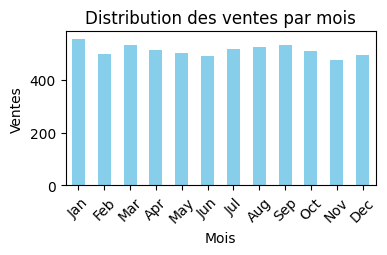

In [47]:
# Representation graphique des ventes par mois
sales_month.plot(kind='bar',figsize=(4, 2), color='skyblue')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec',], rotation=45)
plt.title('Distribution des ventes par mois')
plt.xlabel('Mois')
plt.ylabel('Ventes');

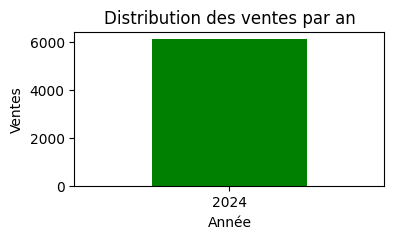

In [48]:
# Representation graphique des ventes par an
sales_year.plot(kind='bar',figsize=(4, 2), color='green')
plt.xticks(rotation=0)
plt.title('Distribution des ventes par an')
plt.xlabel('Année')
plt.ylabel('Ventes');

In [49]:
# Saisons ou des périodes où les ventes sont plus élevées

In [50]:
#-- Definir les saisons
def get_saison(month):
    if month in [12,1,2]:
        return 'Winter' 
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Fall'

In [51]:
#-- Créer la colonne Saison
all_data['Saison'] = all_data['Month'].apply(get_saison)
all_data['Saison'] 

0       Winter
1       Winter
2       Winter
3       Winter
4       Winter
         ...  
6130    Winter
6131    Winter
6132    Winter
6133    Winter
6134    Winter
Name: Saison, Length: 6135, dtype: object

In [52]:
#-- Nombre de ventes par saison
Total_sales_saison = all_data.groupby('Saison')['Revenue'].size()
print('Le nombre de ventes par saison:')
Total_sales_saison

Le nombre de ventes par saison:


Saison
Fall      1516
Spring    1544
Summer    1529
Winter    1546
Name: Revenue, dtype: int64

In [53]:
#-- Chiffre d'affaire par saison
Total_revenue_saison = all_data.groupby('Saison')['Revenue'].sum()
print('Le C.A par saison:')
Total_revenue_saison

Le C.A par saison:


Saison
Fall      313073.0
Spring    326087.5
Summer    315731.0
Winter    328907.5
Name: Revenue, dtype: float64

    # La distribution est homogène. Cependant c'est en Hiver où on enregistre le plus de ventes

# 3- Clients 

## Caractéristiques des clients

In [57]:
all_data.head()

,Sale_ID,Customer_ID,Product_ID,Date,Quantity,Price,Discount,Name,Age,Gender,...,Cost_Price,Supplier_Name,Contact_Person,Contact_Email,City,State,Revenue,Month,Year,Saison
0,1001,C001,P001,2024-01-01,2,20.0,0.050000,Jack Allen,28,F,...,15.00,Gadget World,Emily Rose,emily@gadgetworld.com,New York,NY,40.0,1,2024,Winter
1,1002,C002,P002,2024-01-01,1,35.0,0.100000,Xander Jones,66,F,...,25.00,Tech Gear Co.,John Taylor,john@techgear.com,Los Angeles,CA,35.0,1,2024,Winter
2,1003,C001,P003,2024-01-01,3,15.0,0.000000,Jack Allen,28,F,...,10.00,Circuit Solutions,Mark Johnson,mark@circuitsolutions.com,San Francisco,CA,45.0,1,2024,Winter
3,1004,C056,P005,2024-01-01,4,35.0,0.050000,Carol Lee,20,F,...,30.00,Office Tech Depot,Kevin Lee,kevin@officetechdepot.com,Chicago,IL,140.0,1,2024,Winter
4,1005,C035,P050,2024-01-01,1,20.0,0.059285,Jack Hill,41,M,...,8.75,Sports Tech Gear,Michael Harris,michael@sportstechgear.com,Denver,CO,20.0,1,2024,Winter


In [58]:
# Nombre total de clients uniques
Nbre_customers_uique = all_data['Customer_ID'].nunique()
print('Le nombre de clients unique est de ',Nbre_customers_uique)

Le nombre de clients unique est de  150


In [59]:
# Compter le nombre de clients uniques
unique_customers = all_data['Customer_ID'].nunique()

print(f"Nombre total de clients uniques : {unique_customers}")


Nombre total de clients uniques : 150


In [60]:
# Répartition des clients selon des critères:

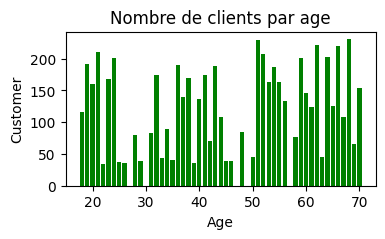

In [61]:
#-- critères Age
Client_age = all_data.groupby('Age')['Customer_ID'].count()
# Graphique
plt.figure(figsize=(4, 2))
plt.bar(Client_age.index, Client_age, color = 'green')
#plt.xticks(Revenue_age.index, rotation=90)
plt.xlabel('Age')
plt.ylabel('Customer')
plt.title("Nombre de clients par age");

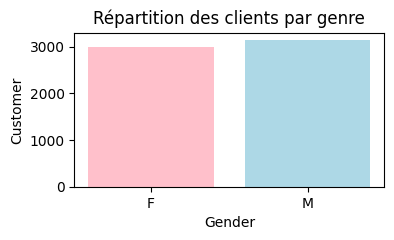

In [62]:
#-- critères Genre
Client_genre = all_data.groupby('Gender')['Customer_ID'].count()
# Graphique
plt.figure(figsize=(4, 2))
plt.bar(Client_genre.index, Client_genre, color = ['pink','lightblue'])
#plt.xticks(Revenue_age.index, rotation=90)
plt.xlabel('Gender')
plt.ylabel('Customer')
plt.title("Répartition des clients par genre");

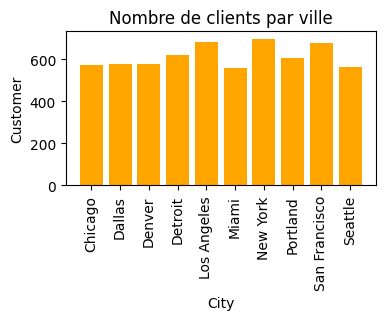

In [63]:
#-- critères de ville
Revenue_ville = all_data.groupby('City')['Customer_ID'].count()
# Graphique
plt.figure(figsize=(4, 2))
plt.bar(Revenue_ville.index, Revenue_ville, color = 'orange')
plt.xticks(rotation=90)
plt.xlabel('City')
plt.ylabel('Customer')
plt.title("Nombre de clients par ville");

In [64]:
# Fréquence des achats par client

In [65]:
print(all_data.columns)

Index(['Sale_ID', 'Customer_ID', 'Product_ID', 'Date', 'Quantity', 'Price',
       'Discount', 'Name', 'Age', 'Gender', 'Region', 'Product_Name',
       'Category', 'Supplier_ID', 'Cost_Price', 'Supplier_Name',
       'Contact_Person', 'Contact_Email', 'City', 'State', 'Revenue', 'Month',
       'Year', 'Saison'],
      dtype='object')


In [66]:
#-- Nombre total de quantité acheté par client
nbre_quantite_achete_par_client = all_data.groupby('Customer_ID')['Quantity'].sum()
nbre_quantite_achete_par_client

Customer_ID
C001    232
C002    271
C003    254
C004    227
C005    117
       ... 
C146    204
C147    279
C148    204
C149    184
C150    267
Name: Quantity, Length: 150, dtype: int64

In [67]:
#-- Nombre de transaction par client
nbre_transaction_par_client = all_data.groupby('Customer_ID').size()
print("le nombre d'achat par client:")
nbre_transaction_par_client

le nombre d'achat par client:


Customer_ID
C001    37
C002    53
C003    39
C004    39
C005    26
        ..
C146    39
C147    46
C148    42
C149    34
C150    51
Length: 150, dtype: int64

In [68]:
#-- Nombre de jour avec une vente
nbre_achat_par_jour = all_data.groupby('Customer_ID')['Date'].nunique()
print('le nombre de jour avec achat par client:')
nbre_achat_par_jour

le nombre de jour avec achat par client:


Customer_ID
C001    35
C002    49
C003    39
C004    38
C005    26
        ..
C146    35
C147    43
C148    41
C149    32
C150    51
Name: Date, Length: 150, dtype: int64

In [69]:
#-- Frequence achat/jour
freq_achat_par_jour = nbre_quantite_achete_par_client / nbre_achat_par_jour
print("la fréquence d'achat par jour:")
freq_achat_par_jour

la fréquence d'achat par jour:


Customer_ID
C001    6.628571
C002    5.530612
C003    6.512821
C004    5.973684
C005    4.500000
          ...   
C146    5.828571
C147    6.488372
C148    4.975610
C149    5.750000
C150    5.235294
Length: 150, dtype: float64

In [70]:
#-- Mettre ces valeurs dans un tableau
Analyse_achat_client = pd.DataFrame({
    'Total_Quantity' : nbre_quantite_achete_par_client,
    'Total_Transaction' : nbre_transaction_par_client,
    'Day_With_Transaction' : nbre_achat_par_jour,
    'Freq_Per_Day' : freq_achat_par_jour
                                    })
Analyse_achat_client

,Total_Quantity,Total_Transaction,Day_With_Transaction,Freq_Per_Day
Customer_ID,,,,
C001,232,37,35,6.628571
C002,271,53,49,5.530612
C003,254,39,39,6.512821
C004,227,39,38,5.973684
C005,117,26,26,4.500000
...,...,...,...,...
C146,204,39,35,5.828571
C147,279,46,43,6.488372
C148,204,42,41,4.975610


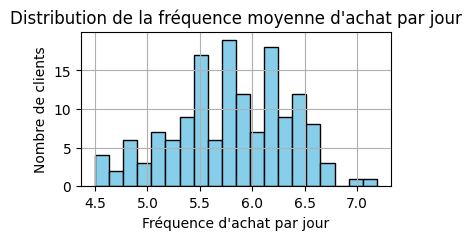

In [71]:
plt.figure(figsize=(4, 2))
Analyse_achat_client['Freq_Per_Day'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution de la fréquence moyenne d'achat par jour")
plt.xlabel("Fréquence d'achat par jour")
plt.ylabel("Nombre de clients")
plt.show()

## Démographie des clients

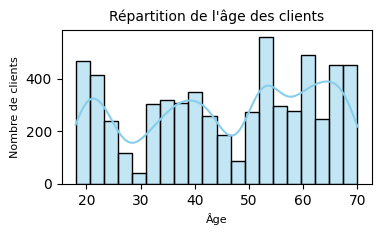

In [73]:
# Répartition de l'age 
plt.figure(figsize=(4, 2))
sns.histplot(all_data['Age'], bins=20, kde=True, color='skyblue')
plt.title("Répartition de l'âge des clients", fontsize=10)
plt.xlabel("Âge", fontsize=8)
plt.ylabel("Nombre de clients", fontsize=8)
plt.show()

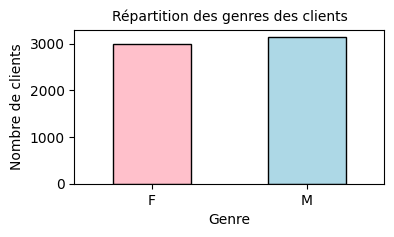

In [74]:
# Distribution du genre: vue dans la partie 3°)
Client_genre = all_data.groupby('Gender')['Customer_ID'].count()
# Equivaut à:
#Client_genre = all_data['Gender'].value_counts()

# Visualisation
plt.figure(figsize=(4, 2))
Client_genre.plot(kind='bar', color=['pink','lightblue'], edgecolor='black')
plt.title("Répartition des genres des clients", fontsize=10)
plt.xlabel("Genre")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=0)
plt.show()

In [75]:
# Groupes dmographiques
#-- Nous avons déjà:
# la répartiton par age : Client_age
# la répartition par genre: Client_genre
# Trouvons la répartition par région: Client_region
Client_region = all_data.groupby('Region')['Customer_ID'].count()
Client_region

Region
East Coast    1242
Midwest       1480
North         1076
South         1204
West Coast    1133
Name: Customer_ID, dtype: int64

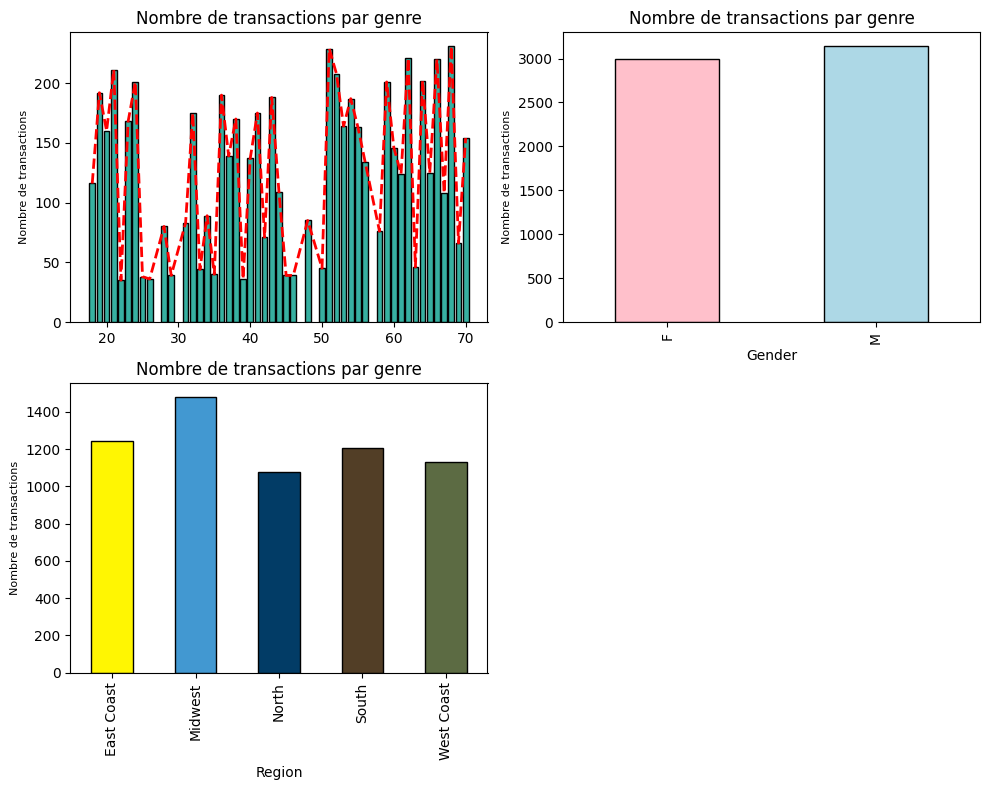

In [76]:
# Visualisations
plt.figure(figsize=(10, 8))

# Age
plt.subplot(2, 2, 1)
plt.bar(Client_age.index, Client_age, color='#37b0a1', edgecolor='black')
# Courbe de tendance
plt.plot(Client_age.index, Client_age, color='r', linestyle='--', linewidth=2)
plt.title("Nombre de transactions par genre")
plt.ylabel("Nombre de transactions", fontsize=8)

# Genre
plt.subplot(2, 2, 2)
Client_genre.plot(kind='bar', color=['pink','lightblue'], edgecolor='black')
plt.title("Nombre de transactions par genre")
plt.ylabel("Nombre de transactions", fontsize=8)

# Region
plt.subplot(2, 2, 3)
Client_region.plot(kind='bar', color=['#fff602','#4298d1','#023c66','#523e26','#5c6b43' ], edgecolor='black')
plt.title("Nombre de transactions par genre")
plt.ylabel("Nombre de transactions", fontsize=8)

plt.tight_layout()

    # Les habitants de la région Midwest agés entre 51 et 56 ans et majoritairement masculins sont les plus actifs
    # Contrairement aux habitants de la région North agés entre 27 et 35 ans sont les moins actifs

# 4- Produits et catégories

## Produits

In [80]:
all_data.columns

Index(['Sale_ID', 'Customer_ID', 'Product_ID', 'Date', 'Quantity', 'Price',
       'Discount', 'Name', 'Age', 'Gender', 'Region', 'Product_Name',
       'Category', 'Supplier_ID', 'Cost_Price', 'Supplier_Name',
       'Contact_Person', 'Contact_Email', 'City', 'State', 'Revenue', 'Month',
       'Year', 'Saison'],
      dtype='object')

In [81]:
# Les produits les plus vendus
#-- Product Name
Best_sale_product_name = all_data.groupby('Product_Name')['Quantity'].sum()
print('La liste des 10 noms des produits les plus vendus:')
Best_sale_product_name.sort_values(ascending=False).head(10)

La liste des 10 noms des produits les plus vendus:


Product_Name
Widget AL       802
Device O        790
Tool BA         751
Accessory T     736
Accessory AN    722
Widget R        720
Item Z          714
Item AJ         710
Gadget AZ       702
Widget A        699
Name: Quantity, dtype: int64

In [82]:
#-- Product ID
Best_sale_product_ID = all_data.groupby('Product_ID')['Quantity'].sum() 
print('La liste des 10 ID des produits les plus vendus:')
Best_sale_product_ID.sort_values(ascending=False).head(10)

La liste des 10 ID des produits les plus vendus:


Product_ID
P038    802
P015    790
P053    751
P020    736
P040    722
P018    720
P026    714
P036    710
P052    702
P001    699
Name: Quantity, dtype: int64

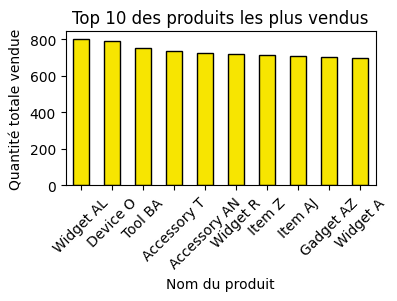

In [83]:
# Visualiser les 10 produits les plus vendus
plt.figure(figsize=(4, 2))
Best_sale_product_name.sort_values(ascending=False).head(10).plot(kind='bar', color='#f7e501', edgecolor='black')
plt.title("Top 10 des produits les plus vendus")
plt.xlabel("Nom du produit")
plt.ylabel("Quantité totale vendue")
plt.xticks(rotation=45)
plt.show();

In [84]:
# Répartition des ventes entre différents catégories de produits
Sales_category_repartition = all_data.groupby('Category')['Quantity'].sum()
#-- Trie par ardre décroissant
Sales_category_repartition.sort_values(ascending=False)

Category
Electronics        10419
Hardware            6801
Home Appliances     6782
Accessories         6465
Office Supplies     3302
Name: Quantity, dtype: int64

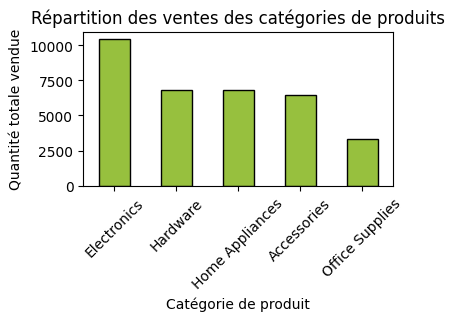

In [85]:
# Visualiser  de la répartition des ventes des catégories de produits
plt.figure(figsize=(4, 2))
Sales_category_repartition.sort_values(ascending=False).plot(kind='bar', color='#97c03e', edgecolor='black')
plt.title("Répartition des ventes des catégories de produits")
plt.xlabel("Catégorie de produit")
plt.ylabel("Quantité totale vendue")
plt.xticks(rotation=45)
plt.show();

In [86]:
# Marge bénéficiaire pour chauque produit
all_data.columns

Index(['Sale_ID', 'Customer_ID', 'Product_ID', 'Date', 'Quantity', 'Price',
       'Discount', 'Name', 'Age', 'Gender', 'Region', 'Product_Name',
       'Category', 'Supplier_ID', 'Cost_Price', 'Supplier_Name',
       'Contact_Person', 'Contact_Email', 'City', 'State', 'Revenue', 'Month',
       'Year', 'Saison'],
      dtype='object')

In [87]:
#-- création de la colonne des marges ['Margin']
all_data['Margin'] = all_data['Price'] - all_data['Cost_Price']

In [88]:
#-- Marge total par produit: les 10 premiers
Marge_par_categorie = all_data.groupby('Product_Name')['Margin'].sum()

In [89]:
print('Top 10 de la marge totale des produits:')
Marge_par_categorie.sort_values(ascending = False).head(10)

Top 10 de la marge totale des produits:


Product_Name
Appliance G     5310.00
Appliance AK    5016.00
Appliance AU    4785.00
Device O        4725.00
Appliance Q     4400.00
Appliance AA    4292.50
Device Y        3900.00
Device AS       3421.25
Device AI       3339.00
Gadget V        3321.00
Name: Margin, dtype: float64

In [90]:
#-- Marge moyenne par produit: les 10 premiers
Marge_par_categorie = all_data.groupby('Product_Name')['Margin'].mean()
print('Top 10 de la marge moyenne des produits:')
Marge_par_categorie.sort_values(ascending = False).head(10)

Top 10 de la marge moyenne des produits:


Product_Name
Appliance G     45.000000
Appliance AK    44.000000
Appliance AA    42.500000
Appliance AU    41.250000
Appliance Q     40.000000
Device O        35.000000
Device Y        32.500000
Device AI       31.500000
Device AS       29.750000
Device E        29.739583
Name: Margin, dtype: float64

## Fournisseurs

In [92]:
# Les fournisseurs qui ont contribué le plus aux ventes

In [93]:
all_data.columns

Index(['Sale_ID', 'Customer_ID', 'Product_ID', 'Date', 'Quantity', 'Price',
       'Discount', 'Name', 'Age', 'Gender', 'Region', 'Product_Name',
       'Category', 'Supplier_ID', 'Cost_Price', 'Supplier_Name',
       'Contact_Person', 'Contact_Email', 'City', 'State', 'Revenue', 'Month',
       'Year', 'Saison', 'Margin'],
      dtype='object')

In [94]:
df_customers.columns

Index(['Customer_ID', 'Name', 'Age', 'Gender', 'Region'], dtype='object')

In [95]:
Top_customer_sale = all_data.groupby('Supplier_Name')['Quantity'].sum().sort_values(ascending = False)
Top_customer_sale

Supplier_Name
Gadget World             3850
Tech Gear Co.            3820
Circuit Solutions        3746
Auto Electronics Pro     3442
Sports Tech Gear         3317
Eco Electronics          3302
Smart Home Essentials    3148
Office Tech Depot        3127
Gourmet Gadgets          3055
HealthTech Supplies      2962
Name: Quantity, dtype: int64

In [96]:
# Graphique interactif sur les fournissuers qui vendent le plus
fig = px.bar(
    Top_customer_sale.reset_index(),# .reset_index() est utile pour réinitialiser l'index
    x='Supplier_Name',
    y='Quantity',
    title="Top fournisseurs par quantité vendue",
    labels={'Supplier_Name': "Nom du fournisseur", 'Quantity': "Quantité totale vendue"},
    color='Quantity',
    color_continuous_scale=px.colors.sequential.Viridis
)

# Ajouter des options interactives
fig.update_layout(
    xaxis_tickangle=45,
    xaxis_title="Nom du fournisseur",
    yaxis_title="Quantité totale vendue",
    template="plotly_white"
)

# Afficher le graphique
fig.show()

In [97]:
# relation entre fournisseur et coût des produits

In [98]:
#-- Cout total par fournisseur
Total_cost_per_customer = all_data.groupby('Supplier_Name')['Cost_Price'].sum().sort_values(ascending=False)
print("Coût total par fournisseur:")
Total_cost_per_customer

Coût total par fournisseur:


Supplier_Name
HealthTech Supplies      23803.50
Office Tech Depot        18265.25
Tech Gear Co.            16898.25
Auto Electronics Pro     13117.25
Gadget World             11496.00
Gourmet Gadgets          10615.50
Circuit Solutions         7813.25
Eco Electronics           7570.00
Sports Tech Gear          4646.50
Smart Home Essentials     3062.50
Name: Cost_Price, dtype: float64

In [99]:
#-- Cout moyen par fournisseur
Average_cost_per_customer = all_data.groupby('Supplier_Name')['Cost_Price'].mean().sort_values(ascending=False)
print("Coût moyen par fournisseur:")
Average_cost_per_customer

Coût moyen par fournisseur:


Supplier_Name
HealthTech Supplies      42.582290
Office Tech Depot        31.932255
Tech Gear Co.            24.777493
Auto Electronics Pro     21.191034
Gourmet Gadgets          18.821809
Gadget World             16.446352
Eco Electronics          12.430213
Circuit Solutions        11.523968
Sports Tech Gear          8.052860
Smart Home Essentials     5.316840
Name: Cost_Price, dtype: float64

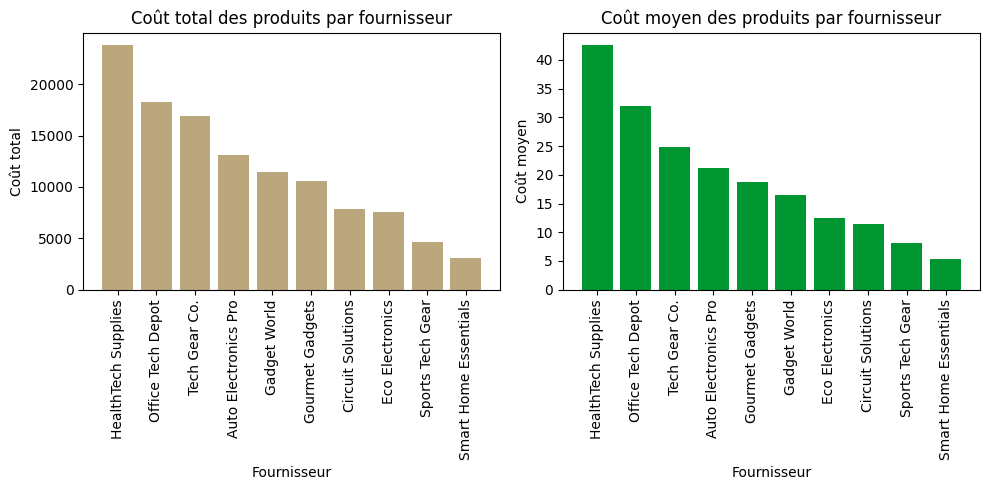

In [100]:
# Graphique des coûts totaux et moyens des produits par fournisseur
plt.figure(figsize=(10, 5))

# Graph coût Total des produits par fournisseur
plt.subplot(1, 2, 1)
plt.bar(Total_cost_per_customer.index, Total_cost_per_customer, color = '#baa77e')
plt.xticks(rotation=90)
plt.xlabel('Fournisseur')
plt.ylabel('Coût total')
plt.title('Coût total des produits par fournisseur')

# Graph coût moyen des produits par fournisseur
plt.subplot(1, 2, 2)
plt.bar(Average_cost_per_customer.index, Average_cost_per_customer, color = '#009632')
plt.xticks(rotation=90)
plt.xlabel('Fournisseur')
plt.ylabel('Coût moyen')
plt.title('Coût moyen des produits par fournisseur')


plt.tight_layout()

C:\Users\diakh\AppData\Local\Temp\ipykernel_252\2714927262.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




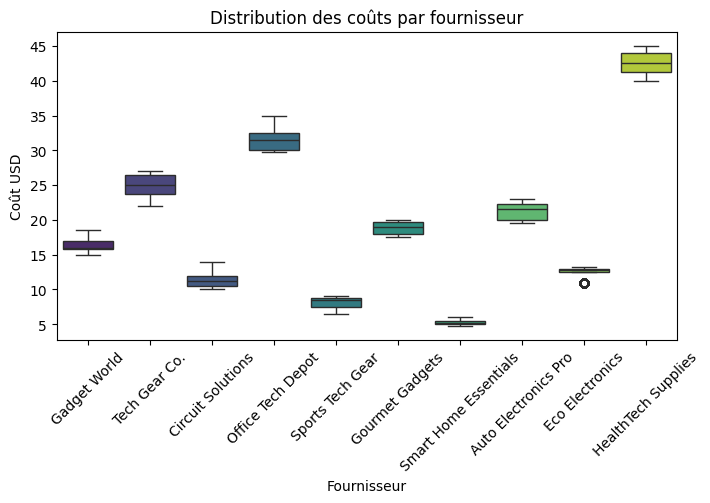

In [101]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=all_data, x='Supplier_Name', y='Cost_Price', palette="viridis")
plt.title("Distribution des coûts par fournisseur")
plt.xlabel("Fournisseur")
plt.ylabel("Coût USD")
plt.xticks(rotation=45)
plt.show()


    # Fournisseurs homogéne: Faible variabilité des prix des produits chez les fournisseurs tels que: Gadget World, Circuit Solutions, Sports Tech Gear, Smart Home Essentials et Eco Electronics (petites boites).    
    # Fournisseurs variés: Forte variabilité chez Tech Gear Co., Office Tech Depot, Auto Electronics Pro et HealthTech Supplies.
    # Fournisseurs dominants: HealthTech Supplies a les coûts les plus élevés qui pourrait cibler les clients qui cherche des produits haute gamme
    # Fournissuer moins cher: Smart Home Essentials cible les clients sensibles aux petits prix
    # Présence d'un outlier chez Eco Electronics: un produit inhabituellement moins cher est visible. Cela pourrait etre dû à une promo.

# 5- Prix et promotions

## Prix et promos

In [105]:
# Relation entre les promos et les ventes

In [106]:
# Grouper les données par niveau de discount
discount_groups = all_data.groupby(pd.cut(all_data['Discount'], bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0])).agg({
    'Quantity': 'sum',
    'Revenue': 'sum'
}).reset_index()

# Renommer les colonnes pour la clarté
discount_groups.rename(columns={'Discount': 'Discount_Range'}, inplace=True)
print("Tableau des tranches de remises en fonction des ventes totales et des revenues totaux")
display(discount_groups)

Tableau des tranches de remises en fonction des ventes totales et des revenues totaux


,Discount_Range,Quantity,Revenue
0,"(0.0, 0.1]",33766,1283754.0
1,"(0.1, 0.2]",0,0.0
2,"(0.2, 0.3]",0,0.0
3,"(0.3, 0.4]",0,0.0
4,"(0.4, 0.5]",0,0.0
5,"(0.5, 1.0]",0,0.0


C:\Users\diakh\AppData\Local\Temp\ipykernel_252\676444808.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\diakh\AppData\Local\Temp\ipykernel_252\676444808.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




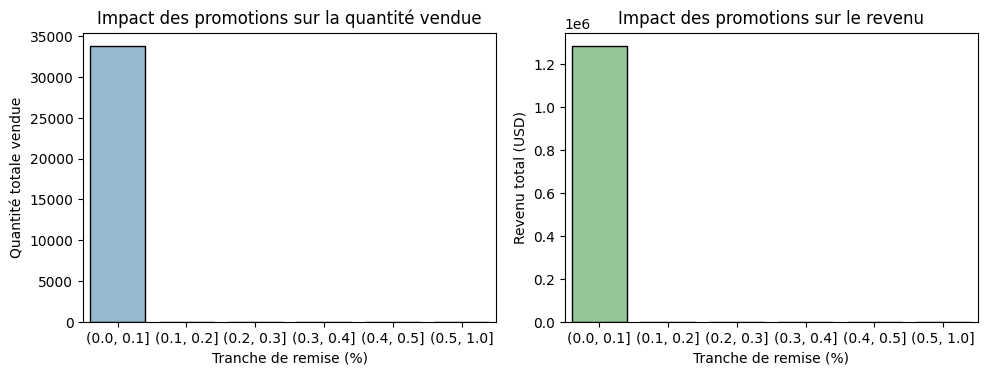

In [107]:
# Visualisation de l'impact du discount sur la quantité vendue
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.barplot(x='Discount_Range', y='Quantity', data=discount_groups, palette='Blues_d', edgecolor='black')
plt.title('Impact des promotions sur la quantité vendue')
plt.xlabel('Tranche de remise (%)')
plt.ylabel('Quantité totale vendue')

# Visualisation de l'impact du discount sur le revenu
plt.subplot(1,2,2)
sns.barplot(x='Discount_Range', y='Revenue', data=discount_groups, palette='Greens_d', edgecolor='black')
plt.title('Impact des promotions sur le revenu')
plt.xlabel('Tranche de remise (%)')
plt.ylabel('Revenu total (USD)')

plt.tight_layout();

    # Seules les promos <= 10% boostent les ventes

In [109]:
all_data.columns

Index(['Sale_ID', 'Customer_ID', 'Product_ID', 'Date', 'Quantity', 'Price',
       'Discount', 'Name', 'Age', 'Gender', 'Region', 'Product_Name',
       'Category', 'Supplier_ID', 'Cost_Price', 'Supplier_Name',
       'Contact_Person', 'Contact_Email', 'City', 'State', 'Revenue', 'Month',
       'Year', 'Saison', 'Margin'],
      dtype='object')

In [110]:
# Statistiques pour Price
price_stats = all_data['Price'].describe()

# Statistiques pour Cost_Price
cost_price_stats = all_data['Cost_Price'].describe()

print("Statistiques pour Price:")
print(price_stats)
print("\nStatistiques pour Cost_Price:")
print(cost_price_stats)

Statistiques pour Price:
count    6135.000000
mean       38.227139
std        21.189540
min         9.500000
25%        22.500000
50%        35.000000
75%        48.000000
max        90.000000
Name: Price, dtype: float64

Statistiques pour Cost_Price:
count    6135.000000
mean       19.117848
std        10.595187
min         4.750000
25%        11.250000
50%        17.500000
75%        24.000000
max        45.000000
Name: Cost_Price, dtype: float64


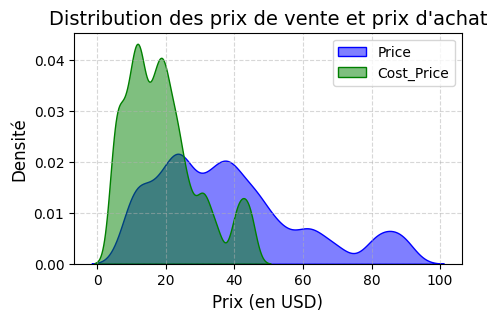

In [111]:
# Distibution entre Cost_Price et Price

# Définir la figure
plt.figure(figsize=(5, 3))

# Tracer les distributions
sns.kdeplot(all_data['Price'], label='Price', color='blue', fill=True, alpha=0.5)
sns.kdeplot(all_data['Cost_Price'], label='Cost_Price', color='green', fill=True, alpha=0.5)

# Ajouter des légendes et titres
plt.title("Distribution des prix de vente et prix d'achat", fontsize=14)
plt.xlabel("Prix (en USD)", fontsize=12)
plt.ylabel("Densité", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Afficher le graphique
plt.show();

## Impact des promotions 

In [113]:
# Promotions qui ont le plus contribué au chiffre d'affaires global 

#-- Création d'un tableau contenant uniquement les tranches (bins) de promo 
discount_bins = all_data.groupby(pd.cut(all_data['Discount'], bins = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0])) 

#-- Création du tableau entre les tranches de promo et le revenue total
Discount_revenue = discount_bins.agg({ 'Revenue' : 'sum'}).reset_index()
#display(Discount_revenue)

#-- Renommons la variable 'Discount' de la table Discount_revenue
print("\nRenommons la variable 'Discount' de la table Discount_revenue pour éviter la confusion avec 'Disount' de all_data:")
Discount_revenue_rename = Discount_revenue.rename(columns={'Discount' : 'Tranche_promo'})
#display(Discount_revenue_rename)

#-- Calcul de la contribution du revenue
total_revenue = Discount_revenue_rename['Revenue'].sum()
contribution = (Discount_revenue_rename['Revenue'] / total_revenue)*100

#-- Ajout de la contribution dans le Tableau:
Discount_revenue_rename['Contribution'] = contribution
print("\nTableau des tranches de promos, du revenue total et de la contribution des revenues (%)")
display(Discount_revenue_rename)


Renommons la variable 'Discount' de la table Discount_revenue pour éviter la confusion avec 'Disount' de all_data:

Tableau des tranches de promos, du revenue total et de la contribution des revenues (%)


,Tranche_promo,Revenue,Contribution
0,"(0.0, 0.1]",1283754.0,100.0
1,"(0.1, 0.2]",0.0,0.0
2,"(0.2, 0.3]",0.0,0.0
3,"(0.3, 0.4]",0.0,0.0
4,"(0.4, 0.5]",0.0,0.0
5,"(0.5, 1.0]",0.0,0.0


    # Les promos inférieures ou égales à 10% contribuent à 100% du chiffre d'affaire

In [115]:
# Corrélation entre le montant des promotions et la quantité vendue

correlation_promo_quantite = all_data['Discount'].corr(all_data['Quantity'])
print(f"Corrélation entre Montant des Promotions et Quantité Vendue : {correlation_promo_quantite:.2f}")

Corrélation entre Montant des Promotions et Quantité Vendue : -0.01


    # Nous avons une corrélation de -0.01, ce qui signifie que, dans ce cas, le montant des promotions a une très faible relation avec la quantité vendue

# 6- Relation entre les variables

## Corelations

In [119]:
# Correlations entre Price, Discount Quantity, Age et Gender

#-- Changement de la variable catégorielle 'Gender' en variable continue
print(all_data['Gender'])

0       F
1       F
2       F
3       F
4       M
       ..
6130    M
6131    M
6132    M
6133    M
6134    F
Name: Gender, Length: 6135, dtype: object


In [120]:
all_data['Gender'] = all_data['Gender'].map({'M':0, 'F':1})
print(all_data['Gender'])

0       1
1       1
2       1
3       1
4       0
       ..
6130    0
6131    0
6132    0
6133    0
6134    1
Name: Gender, Length: 6135, dtype: int64


In [121]:
variables = ['Price', 'Discount', 'Quantity', 'Age', 'Gender']
correlation_matrix = all_data[variables].corr()
correlation_matrix

,Price,Discount,Quantity,Age,Gender
Price,1.000000,0.019318,-0.019048,0.008934,-0.000355
Discount,0.019318,1.000000,-0.010434,0.008038,-0.017013
Quantity,-0.019048,-0.010434,1.000000,0.004811,-0.006822
Age,0.008934,0.008038,0.004811,1.000000,-0.049551
Gender,-0.000355,-0.017013,-0.006822,-0.049551,1.000000


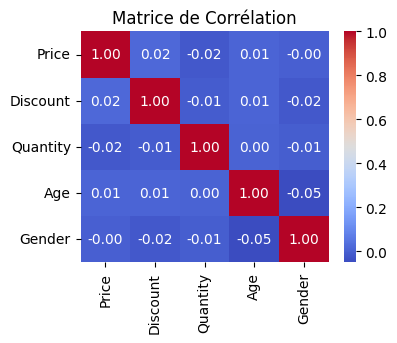

In [122]:
# Création d'une heatmap
plt.figure(figsize=(4, 3))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation")
plt.show();

        # Correlation entre Price, Discount,Quantity
- Price vs Quantity: -0.02 faible correlation négative. Quand le prix baisse la quantité augmente
- Price vs Discount: 0.02 faible correlation positive. Quand le prix augmente le discount augmente aussi
- Discount vs Quantity: -0.01 très faible correlation négative entre la quantité et les promos
        # Correlation Age
- Age vs Price: et Age vs Discount: 0.01 très faible correlation de l'Age avec le prix et le Discount
- Age vs Quantity: 0.00 pas de correlation. L'age des clients n'influe pas sur la quantité achetée.
        # Correlation Gender
- Gender vs Price: 0.00 pas de correlation. Le sexe des clients n'a pas de rapport avec le prix des produits
- Gender vs Quantity: -0.01 très faible correlation négative entre le genre et la quantité

In [124]:
# Relation entre les regions (city, region, state) et les ventes

all_data.columns

Index(['Sale_ID', 'Customer_ID', 'Product_ID', 'Date', 'Quantity', 'Price',
       'Discount', 'Name', 'Age', 'Gender', 'Region', 'Product_Name',
       'Category', 'Supplier_ID', 'Cost_Price', 'Supplier_Name',
       'Contact_Person', 'Contact_Email', 'City', 'State', 'Revenue', 'Month',
       'Year', 'Saison', 'Margin'],
      dtype='object')

In [125]:
#-- Ventes vs Regions
Sales_region = all_data.groupby('Region')['Revenue'].sum().sort_values(ascending=False)

#-- Ventes vs City
Sales_city = all_data.groupby('City')['Revenue'].sum().sort_values(ascending=False)

#-- Ventes vs State
Sales_state = all_data.groupby('State')['Revenue'].sum().sort_values(ascending=False)

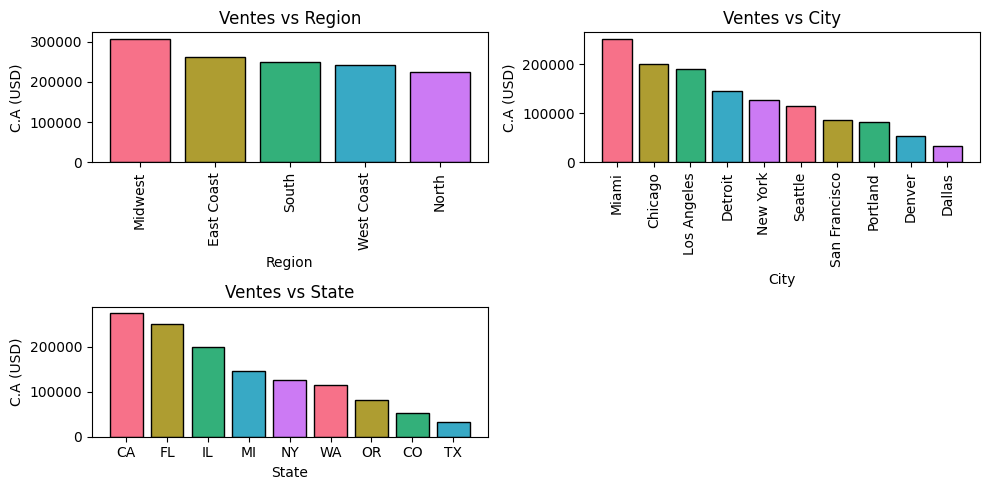

In [126]:
#-- Générer une palette aléatoire
#colors= [plt.cm.tab10(np.random.randint(0, 15)) for _ in range(len(all_data))]
colors = sns.color_palette("husl", len(Sales_region))

#-- Graphique Vente vs Region
plt.figure(figsize=(10,5))
plt.subplot(2,2,1)
plt.bar(Sales_region.index, Sales_region, color = colors, edgecolor = 'black')
plt.xticks(rotation = 90)
plt.xlabel('Region')
plt.ylabel('C.A (USD)')
plt.title('Ventes vs Region')

#-- Graphique Vente vs City
plt.subplot(2,2,2)
plt.bar(Sales_city.index, Sales_city, color = colors, edgecolor = 'black')
plt.xticks(rotation = 90)
plt.xlabel('City')
plt.ylabel('C.A (USD)')
plt.title('Ventes vs City')

#-- Graphique Vente vs State
plt.subplot(2,2,3)
plt.bar(Sales_state.index, Sales_state, color = colors, edgecolor = 'black')
plt.xticks(rotation = 0)
plt.xlabel('State')
plt.ylabel('C.A (USD)')
plt.title('Ventes vs State')

plt.tight_layout();

In [127]:
Sales_region_percentage = Sales_region / Sales_region.sum() * 100
print(Sales_region_percentage)

Region
Midwest       23.986387
East Coast    20.362378
South         19.361481
West Coast    18.846330
North         17.443424
Name: Revenue, dtype: float64


In [128]:
Sales_city_percentage = Sales_city / Sales_city.sum() * 100
print(Sales_city_percentage)

City
Miami            19.629007
Chicago          15.581762
Los Angeles      14.723722
Detroit          11.362410
New York          9.862876
Seattle           8.936095
San Francisco     6.732090
Portland          6.413037
Denver            4.154194
Dallas            2.604808
Name: Revenue, dtype: float64


In [129]:
Sales_state_percentage = Sales_state / Sales_state.sum() * 100
print(Sales_state_percentage)

State
CA    21.455812
FL    19.629007
IL    15.581762
MI    11.362410
NY     9.862876
WA     8.936095
OR     6.413037
CO     4.154194
TX     2.604808
Name: Revenue, dtype: float64


    # 24% des ventes regionales sont éffectuées dans le Midwest
    # 20% des ventes par city sont éffectuées à Miami
    # 21% des ventes par state sont éffectuées à CA

## Clustering

In [132]:
# Groupe d'age
age_bins = [0,18,35,50,65,100]
age_label = ['<18', '18-35', '36-50', '51-65', '65+']
all_data['Age_Group']  = pd.cut(all_data['Age'], bins = age_bins, labels = age_label)
display(all_data[['Age', 'Age_Group']].head())

,Age,Age_Group
0,28,18-35
1,66,65+
2,28,18-35
3,20,18-35
4,41,36-50


In [133]:
# Groupe de genre
sales_by_gender = all_data.groupby('Gender')['Revenue'].sum().sort_values(ascending=False)
print(sales_by_gender)

Gender
0    660136.5
1    623662.5
Name: Revenue, dtype: float64


In [134]:
# Groupe de region
sales_by_region = all_data.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
print(sales_by_region)

Region
Midwest       307937.0
East Coast    261412.0
South         248562.5
West Coast    241949.0
North         223938.5
Name: Revenue, dtype: float64


In [135]:
# Groupe de produit
sales_by_product = all_data.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
print(sales_by_product)

Category
Electronics        472528.5
Home Appliances    441020.0
Hardware           201148.0
Accessories         86772.0
Office Supplies     82330.5
Name: Revenue, dtype: float64


In [136]:
# Groupe profile financier
finance_bin = [0, 100, 500, 1000, 5000, 10000]
finance_label = ['Très faible', 'Faible', 'Moyen', 'Élevé', 'Très élevé']
all_data['Finance_Group']  = pd.cut(all_data['Revenue'], bins = finance_bin, labels = finance_label)
display(all_data[['Revenue', 'Finance_Group']].head())

,Revenue,Finance_Group
0,40.0,Très faible
1,35.0,Très faible
2,45.0,Très faible
3,140.0,Faible
4,20.0,Très faible


In [137]:
# Table croisé des segments
segments = all_data.groupby(['Age_Group', 'Region'])['Revenue'].mean()
display(round(segments,2))

Age_Group  Region    
<18        East Coast       NaN
           Midwest          NaN
           North         159.78
           South            NaN
           West Coast    246.04
18-35      East Coast    218.98
           Midwest       218.39
           North         206.87
           South         199.33
           West Coast    203.79
36-50      East Coast    201.37
           Midwest       208.62
           North         217.71
           South         203.60
           West Coast    215.77
51-65      East Coast    214.13
           Midwest       199.91
           North         202.54
           South         213.23
           West Coast    216.09
65+        East Coast    214.53
           Midwest       200.10
           North         266.84
           South         206.79
           West Coast    210.96
Name: Revenue, dtype: float64

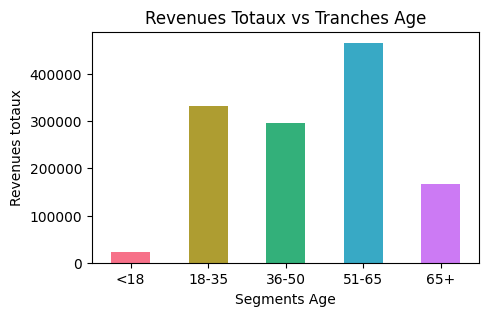

In [138]:
# Graph segment des revenues totaux en fonction du segment d'age
revenue_segment_age = all_data.groupby('Age_Group')['Revenue'].sum()
revenue_segment_age.plot(kind = 'bar',color=colors, figsize=(5, 3))
plt.xticks(rotation = 0)
plt.xlabel('Segments Age')
plt.ylabel('Revenues totaux')
plt.title('Revenues Totaux vs Tranches Age')
plt.show()

    # Les personnes agées entre 51-65 achétent le plus

# 7- Exploration et visualisation 

## Visualisation

In [142]:
# Répartition géographique des ventes
#-- Agréger les ventes par City, State
city_revenue = all_data.groupby(['City', 'State']).agg({'Revenue': 'sum'}).reset_index()
city_revenue

,City,State,Revenue
0,Chicago,IL,200038.5
1,Dallas,TX,33440.5
2,Denver,CO,53331.5
3,Detroit,MI,145870.5
4,Los Angeles,CA,189023.0
5,Miami,FL,251997.0
6,New York,NY,126619.5
7,Portland,OR,82330.5
8,San Francisco,CA,86426.5
9,Seattle,WA,114721.5


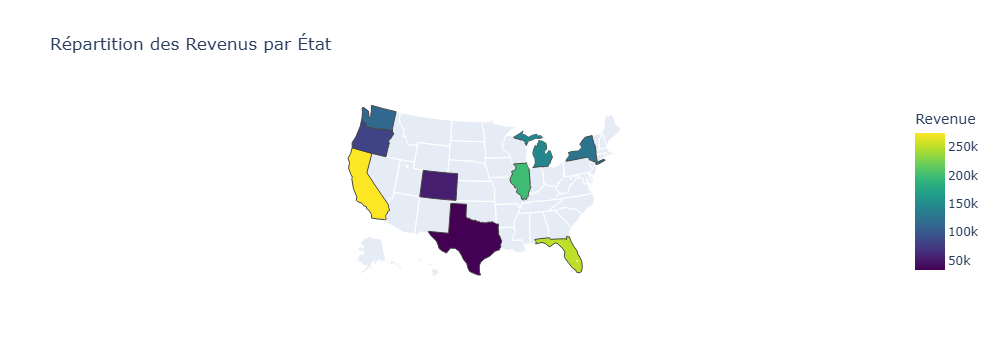

In [143]:
# Agréger les ventes par état
state_revenue = all_data.groupby('State').agg({'Revenue': 'sum'}).reset_index()

# Tracer une carte choroplèthe
fig = px.choropleth(
    state_revenue,
    locations='State',  # Les codes d'états (ex: 'CA', 'NY', etc.)
    locationmode='USA-states',  # Mode pour les états américains
    color='Revenue',  # Variable à visualiser
    color_continuous_scale="Viridis",
    scope="usa",  # Limiter la carte aux USA
    title="Répartition des Revenus par État"
)

fig.show()

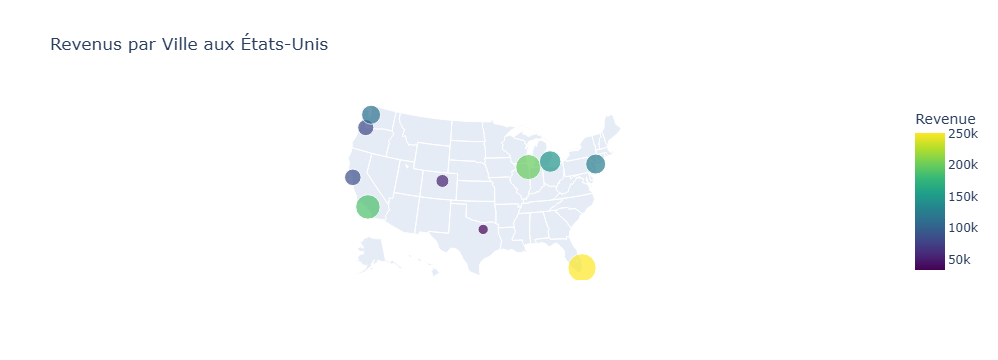

In [273]:
import plotly.express as px
import pandas as pd

# Données des villes
data = {
    "City": ["Chicago", "Dallas", "Denver", "Detroit", "Los Angeles", 
             "Miami", "New York", "Portland", "San Francisco", "Seattle"],
    "State": ["IL", "TX", "CO", "MI", "CA", "FL", "NY", "OR", "CA", "WA"],
    "Revenue": [200038.5, 33440.5, 53331.5, 145870.5, 189023.0, 
                251997.0, 126619.5, 82330.5, 86426.5, 114721.5],
    "Latitude": [41.8781, 32.7767, 39.7392, 42.3314, 34.0522, 
                 25.7617, 40.7128, 45.5051, 37.7749, 47.6062],
    "Longitude": [-87.6298, -96.7970, -104.9903, -83.0458, -118.2437, 
                  -80.1918, -74.0060, -122.6750, -122.4194, -122.3321]
}

# Création d'un DataFrame
df = pd.DataFrame(data)

# Créer un graphique choropleth
fig = px.scatter_geo(
    df,
    lat='Latitude',
    lon='Longitude',
    size='Revenue',  # Taille des points basée sur les revenus
    color='Revenue',  # Couleur basée sur les revenus
    hover_name='City',  # Affichage au survol
    title="Revenus par Ville aux États-Unis",
    color_continuous_scale="Viridis",  # Palette de couleurs
    scope="usa"  # Limiter la carte aux USA
)

# Afficher le graphique
fig.show()

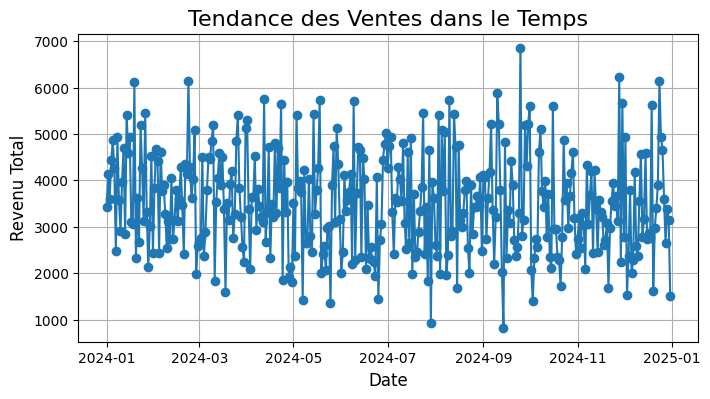

In [375]:
# Tendances des ventes dans le temps
Sales_time_trend = all_data.groupby('Date').agg({'Revenue': 'sum'}).reset_index()
plt.figure(figsize=(8, 4))
plt.plot(Sales_time_trend['Date'], Sales_time_trend['Revenue'], marker='o', linestyle='-')
plt.title("Tendance des Ventes dans le Temps", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Revenu Total", fontsize=12)
plt.grid()
plt.show()

In [415]:
# Graphiques les plus pertinents pour visualiser la performance des ventes et des produits ?
#-- Texte à mettre dans mon tableau
data_texte = {
    "Objectif": ["Tendance dans le temps", "Répartition géographique", "Performance des produits", "Analyse des marges", 
                 "Los Analyse des clients", "Saisonnalité"],
    "Graphique": ["Line Plot, Histogramme", "Choropleth, Heatmap", "Treemap, Bar Chart", "Box Plot, Stacked Bars", 
                  "Histogramme, Scatter", "Grouped Bars, Line Plot"],
    "Outil recommandé": ["Matplotlib, Plotly", "Plotly, Folium", "Plotly", "Plotly, Seaborn", "Plotly, Seaborn", "Plotly"]
}

#-- Création d'un tableau
Tableau_graph = pd.DataFrame(data_texte)

In [417]:
Tableau_graph

,Objectif,Graphique,Outil recommandé
0,Tendance dans le temps,"Line Plot, Histogramme","Matplotlib, Plotly"
1,Répartition géographique,"Choropleth, Heatmap","Plotly, Folium"
2,Performance des produits,"Treemap, Bar Chart",Plotly
3,Analyse des marges,"Box Plot, Stacked Bars","Plotly, Seaborn"
4,Los Analyse des clients,"Histogramme, Scatter","Plotly, Seaborn"
5,Saisonnalité,"Grouped Bars, Line Plot",Plotly


# 8- Performances des ventes

## Analyse des performances

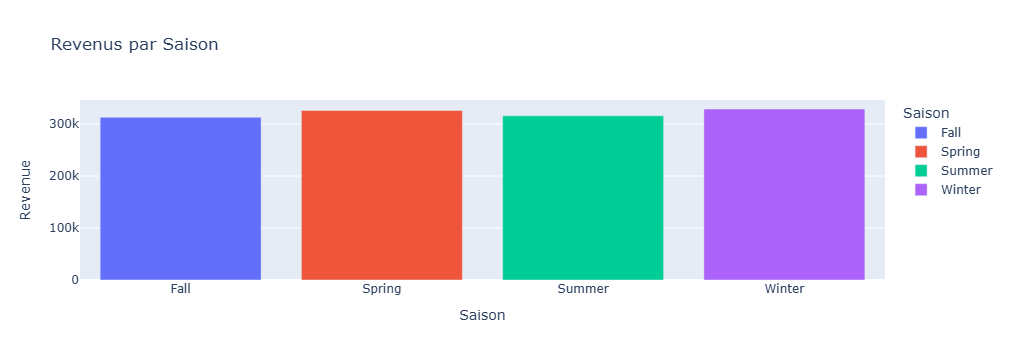

Les ventes sont relativement similaire pour les 4 saisons


In [469]:
# Tendances les plus significatives qui influencent les ventes

#-- Saisonnalité
Saison_trend = all_data.groupby('Saison').agg({'Revenue': 'sum'}).reset_index()
#display(Saison_trend)

# Graphique
fig = px.bar(Saison_trend, x='Saison', y='Revenue', title='Revenus par Saison', color='Saison')
fig.show()
print("Les ventes sont relativement similaire pour les 4 saisons")

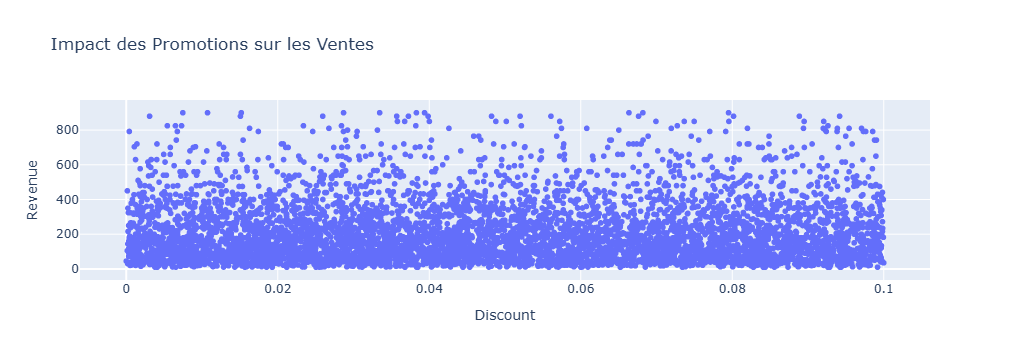

In [439]:
#-- Les Promotions
Discount_trend = all_data.groupby('Discount').agg({'Revenue': 'sum'}).reset_index()

# Graphique des Promos vs Revenues
fig = px.scatter(Discount_trend, x='Discount', y='Revenue', title="Impact des Promotions sur les Ventes")
fig.show()

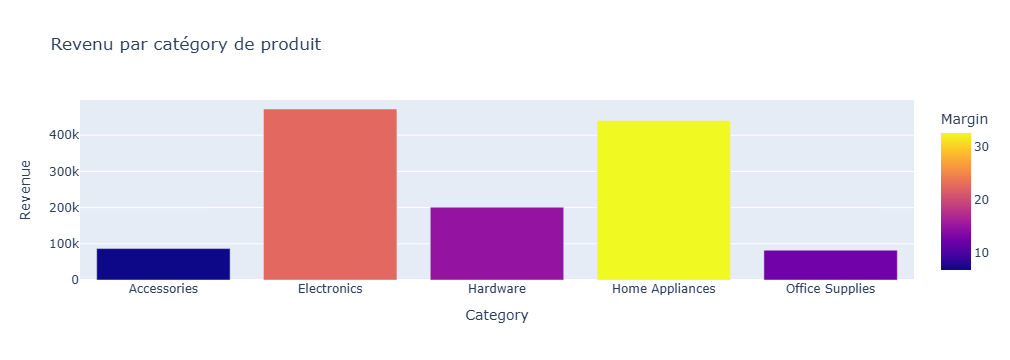

# Les produits electronique et home Appliabces sont ceux qui génèrent le plus de revenues donc de marge


In [461]:
#-- Les catégories de produits en fonction des revenues de la marge moyenne réalisée
category_trend = all_data.groupby('Category').agg({'Revenue': 'sum', 'Margin': 'mean'}).reset_index()

# Graphique
fig = px.bar(category_trend , x = 'Category', y = 'Revenue', title = 'Revenu par catégory de produit', color = 'Margin')
fig.show()

print("# Les produits electronique et home Appliabces sont ceux qui génèrent le plus de revenues donc de marge")

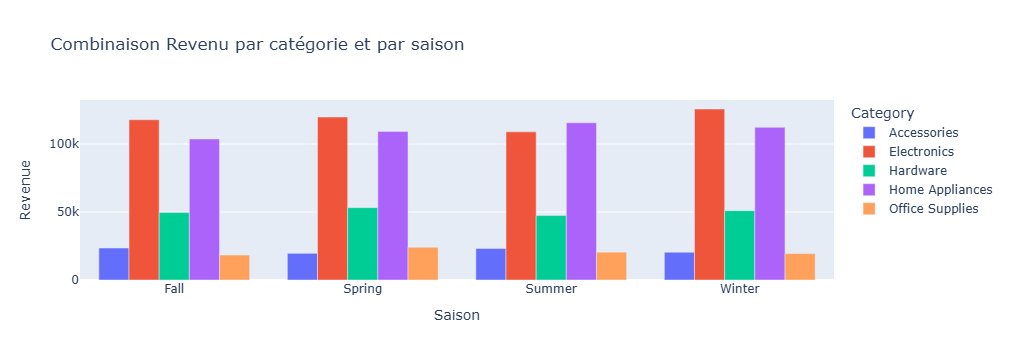

In [483]:
#-- Combinaison de facteurs: saison, catégory et revenue
Combinaison_trend = all_data.groupby(['Saison', 'Category']).agg({'Revenue': 'sum'}).reset_index()

# Graphique 
fig = px.bar(Combinaison_trend, x='Saison', y='Revenue', color='Category', barmode='group', 
            title='Combinaison Revenu par catégorie et par saison')
fig.show()

In [485]:
all_data.columns

Index(['Sale_ID', 'Customer_ID', 'Product_ID', 'Date', 'Quantity', 'Price',
       'Discount', 'Name', 'Age', 'Gender', 'Region', 'Product_Name',
       'Category', 'Supplier_ID', 'Cost_Price', 'Supplier_Name',
       'Contact_Person', 'Contact_Email', 'City', 'State', 'Revenue', 'Month',
       'Year', 'Saison', 'Margin', 'Age_Group', 'Finance_Group'],
      dtype='object')

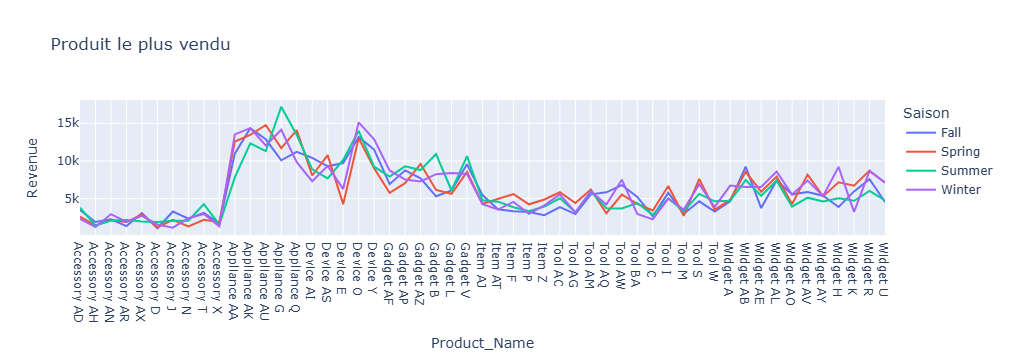

In [541]:
# Produits ou catégories ayant vu une augmentation ou une diminution des ventes au fil du temps
#-- Combinaison de facteurs: saison, catégory et revenue
Combinaison_prod_trend = all_data.groupby(['Saison', 'Product_Name']).agg({'Revenue': 'sum'}).reset_index()

# Graphique 
fig = px.line(Combinaison_prod_trend, x='Product_Name', y='Revenue', color='Saison',  
            title='Produit le plus vendu')
fig.show()

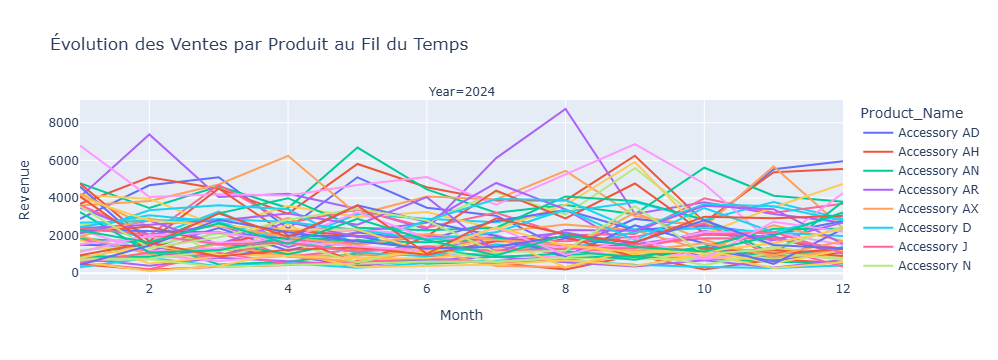

In [529]:
#-- Grouper les ventes par nom de produit et par année et mois
sales_trend = all_data.groupby(['Product_Name', 'Year', 'Month']).agg({'Revenue': 'sum'}).reset_index()

# Visualisation de la tendance des ventes
fig = px.line(sales_trend, x='Month', y='Revenue', color='Product_Name', 
              facet_col='Year', title='Évolution des Ventes par Produit au Fil du Temps')
fig.show()

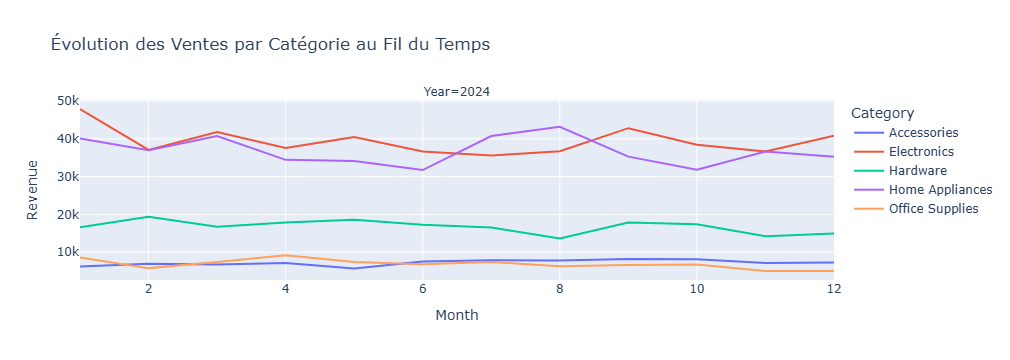

In [530]:
#-- Grouper les ventes par catégorie et par année et mois
sales_trend_category = all_data.groupby(['Category', 'Year', 'Month']).agg({'Revenue': 'sum'}).reset_index()

fig = px.line(sales_trend_category, x='Month', y='Revenue', color='Category', 
              facet_col='Year', title='Évolution des Ventes par Catégorie au Fil du Temps')
fig.show()
